<a href="https://colab.research.google.com/github/zaporozhetsalena/My-first-project/blob/main/HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [5]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [6]:
month_year = df['month_year']

In [7]:
df.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,month_year
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,2011-01
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,2011-01


In [11]:
df.index = pd.to_datetime(df.index)

In [12]:
df['month_year'] = df.index.to_period('M').astype(str)


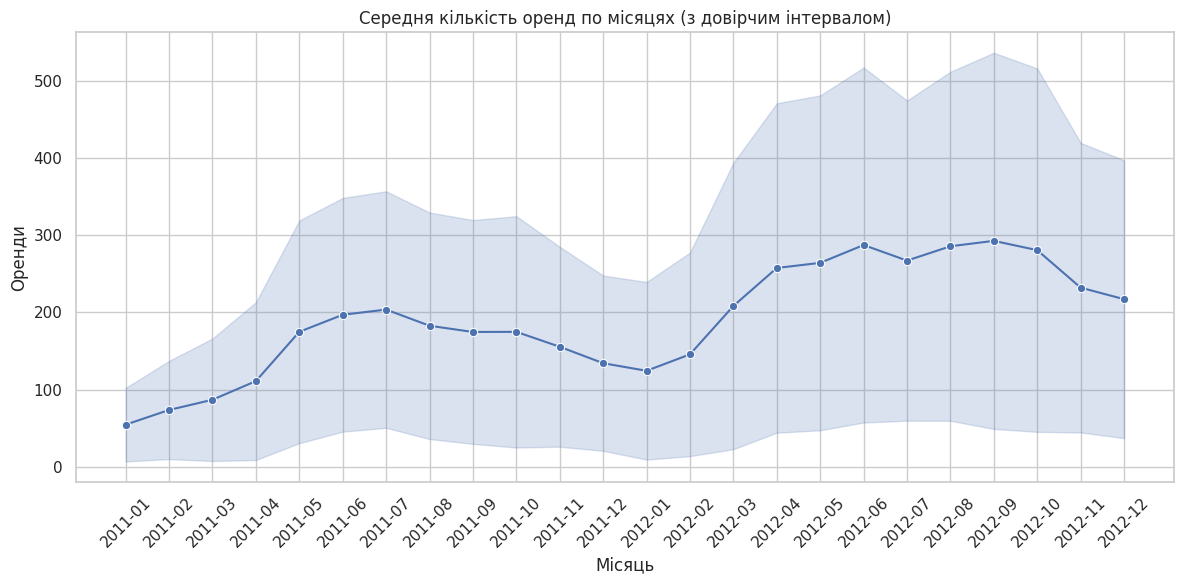

In [13]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df,
             marker='o',
             x='month_year',
             y='count',
             errorbar='sd')

plt.xticks(rotation=45)
plt.title("Середня кількість оренд по місяцях (з довірчим інтервалом)")
plt.xlabel("Місяць")
plt.ylabel("Оренди")
plt.tight_layout()
plt.show()

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

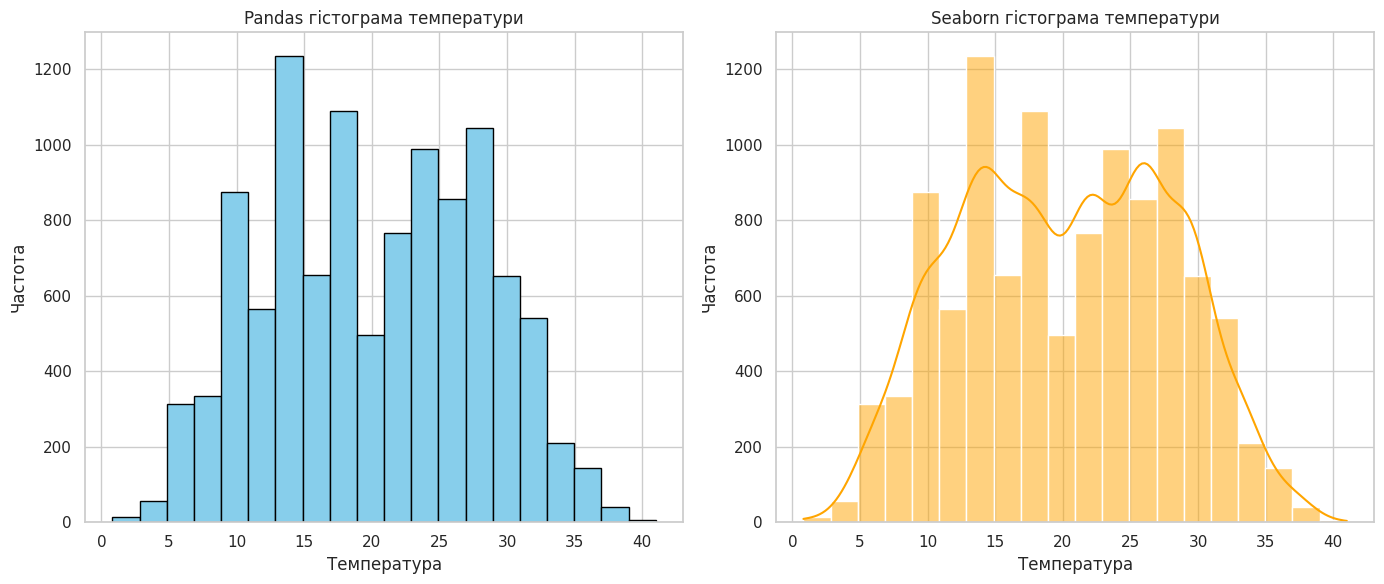

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

#  Pandas
df['temp'].plot.hist(
    bins=20,                  # однакова (не стандартна) кількість бінів
    ax=ax[0],
    color='skyblue',
    edgecolor='black'
)
ax[0].set_title("Pandas гістограма температури")
ax[0].set_xlabel("Температура")
ax[0].set_ylabel("Частота")

# Seaborn
sns.histplot(
    data=df,
    x='temp',
    bins=20,                  # та сама кількість бінів
    kde=True,                 # додаємо KDE
    ax=ax[1],
    color='orange'
)
ax[1].set_title("Seaborn гістограма температури")
ax[1].set_xlabel("Температура")
ax[1].set_ylabel("Частота")

plt.tight_layout()
plt.show()

Pandas: проста гістограма — тільки стовпчики, мінімум стилізації.
Seaborn: більш “гладкий” і сучасний вигляд, кращі кольори + додаткова лінія розподілу.

Seaborn виглядає більш професійно та інформативно.

Що за додаткова лінія?

Це KDE (Kernel Density Estimate)
KDE — це плавна лінія, яка показує загальну форму розподілу даних.
Тобто: це “згладжена гістограма”
показує, де значення зустрічаються частіше
допомагає краще побачити тренд

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

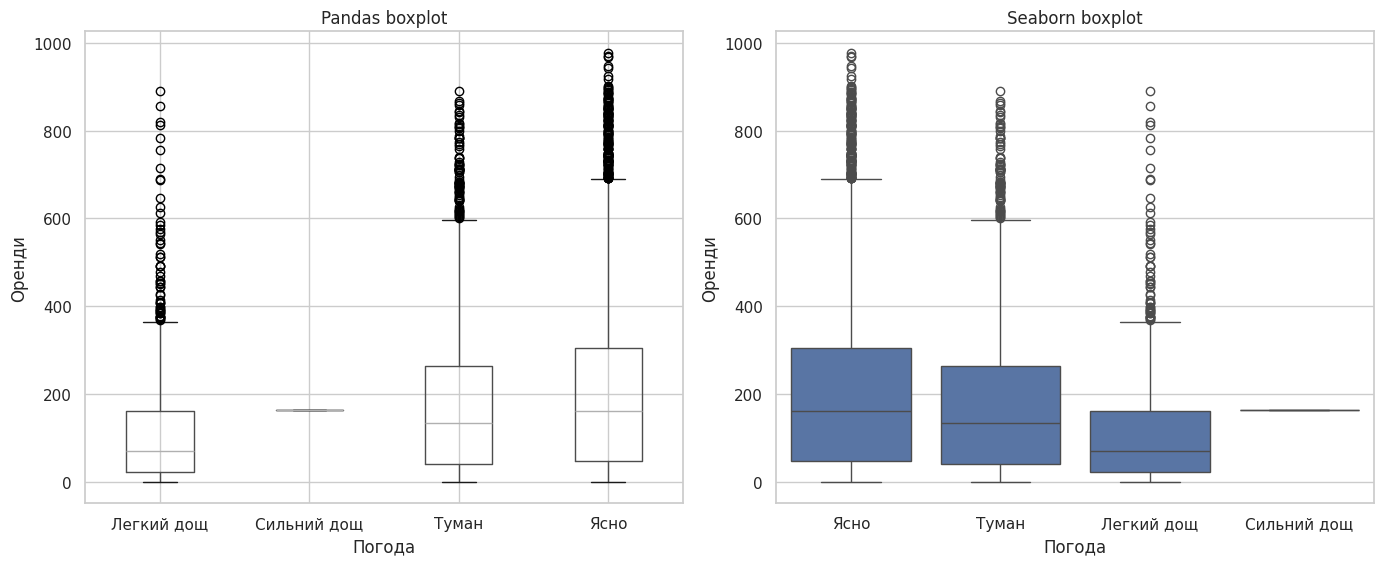

In [33]:
# мапа
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

df['weather_label'] = df['weather'].map(weather_labels)

fig, ax = plt.subplots(1, 2, figsize=(14,6))

# Pandas
df.boxplot(column='count', by='weather_label', ax=ax[0])
ax[0].set_title("Pandas boxplot")
ax[0].set_xlabel("Погода")
ax[0].set_ylabel("Оренди")

# прибрати зайвий заголовок
plt.suptitle('')

# Seaborn
sns.boxplot(data=df, x='weather_label', y='count', ax=ax[1])
ax[1].set_title("Seaborn boxplot")
ax[1].set_xlabel("Погода")
ax[1].set_ylabel("Оренди")

plt.tight_layout()
plt.show()

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


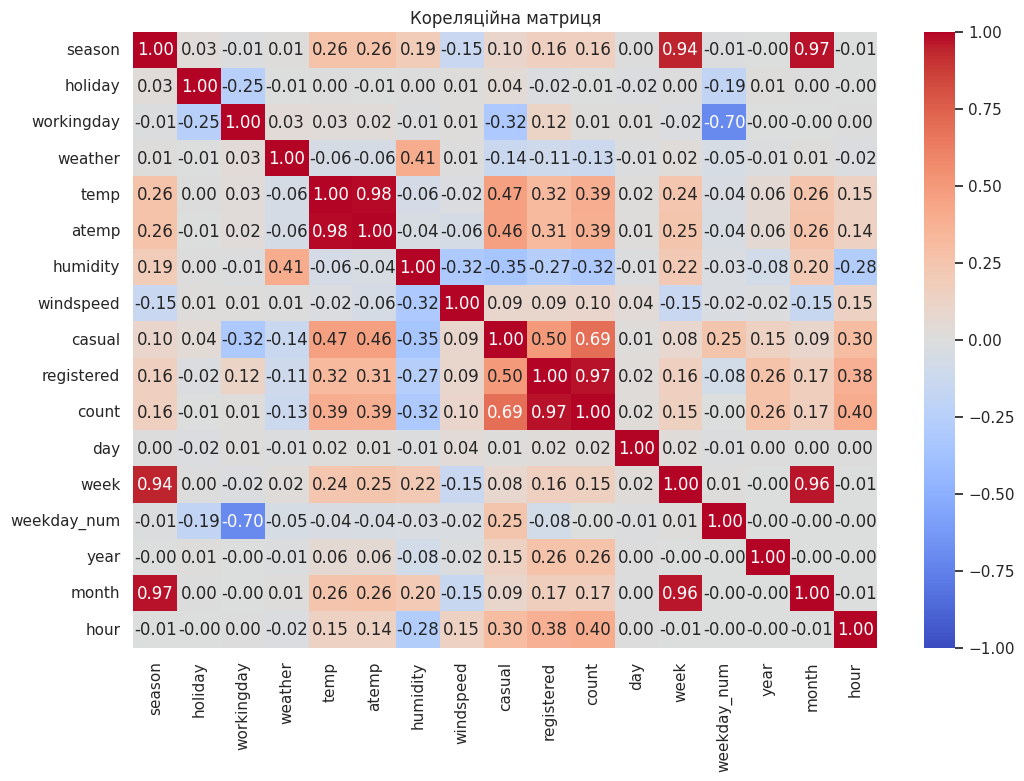

In [31]:
# беремо тільки числові колонки
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(corr,
            annot=True,        # показати значення
            cmap='coolwarm',   # кольори
            fmt=".2f", # 2 знаки після коми
            vmin=-1,
            vmax=1)

plt.title("Кореляційна матриця")
plt.show()

Count найбільше корелює з registered та casual
temp і atemp мають майже ідеальну кореляцію, бо пов’язані між собою
негативна кореляція спостерігається у humidity та windspeed

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


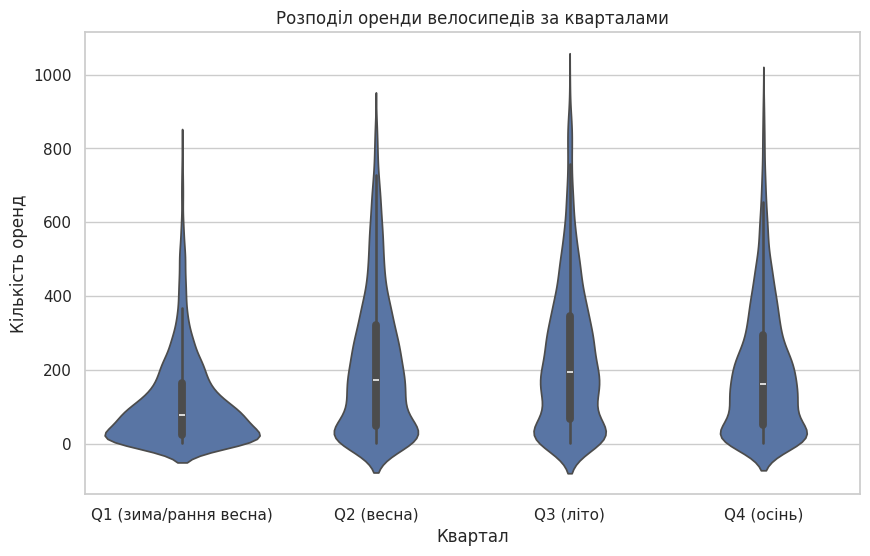

In [24]:
# (за бажанням — підписи кварталів)
season_labels = {
    1: 'Q1 (зима/рання весна)',
    2: 'Q2 (весна)',
    3: 'Q3 (літо)',
    4: 'Q4 (осінь)'
}
df['season_label'] = df['season'].map(season_labels)

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='season_label',   # або просто 'season'
    y='count',
    inner='box'         # маленький boxplot всередині
)

plt.title("Розподіл оренди велосипедів за кварталами")
plt.xlabel("Квартал")
plt.ylabel("Кількість оренд")

plt.show()

1. Що показує "товщина" violin plot?

Товщина показує щільність даних

товсто → багато значень
тонко → мало значень

2. В якому кварталі найбільша варіабельність?

 зазвичай у цьому датасеті:

Q3 (літо)

багато оренд
великий розкид (і низькі, і дуже високі значення)
3. Перевага violin plot над box plot

 violin plot показує більше інформації

Box plot:

тільки медіана, квартилі, викиди

Violin plot:

форма розподілу
щільність значень
де дані концентруються
КОРОТКО (для здачі)
Товщина показує щільність значень
Найбільша варіабельність — у Q3
Перевага: violin plot показує форму розподілу, а не тільки статистику

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

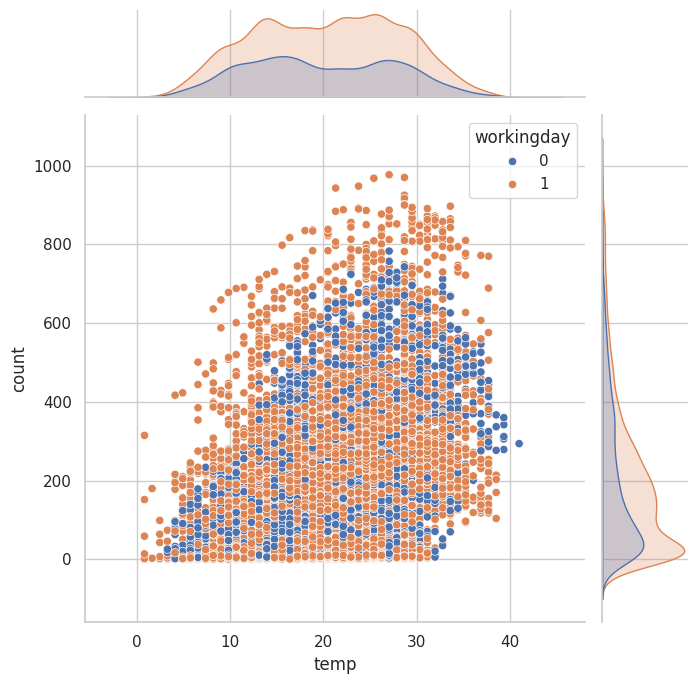

In [25]:
sns.jointplot(
    data=df,
    x='temp',
    y='count',
    hue='workingday',   # розбивка: 0/1
    kind='scatter',
    height=7
)

plt.show()

Це розподіли кожної змінної окремо

зверху → розподіл температури (temp)
справа → розподіл кількості оренд (count)

Чи є різниця між робочими і неробочими днями?

Так, є
у робочі дні (1):
більше високих значень оренд
більш стабільний попит
у вихідні (0):
більше варіативності
можуть бути як низькі, так і дуже високі значення
Висновок:
у робочі дні люди використовують велосипеди регулярно (дорога на роботу)
у вихідні — поведінка більш випадкова (відпочинок, погода сильніше впливає)